# Online Policy Evolution — combined (arrival + departure)

Supersedes `online_policy_evolution.ipynb` and `online_departure_policy_evolution.ipynb`. Value iteration is the bottleneck, so this notebook runs it **once per epoch** and then renders **both** the arrival-policy and departure-policy figures from the same `DiscretizedDPAgent`.

Pipeline per epoch:
1. Slice `degradation_history` up to the customer index at which retraining was triggered.
2. Re-fit a `DegradationLearner` (Cox PH + Breslow baseline) on that prefix.
3. Build a `DiscretizedDPAgent` with `û` = `u_hat_final` and the re-fit learner, run value iteration **(expensive step, ~2–3 min at full fidelity — done only once per epoch)**.
4. Render arrival plot (1×3 heatmaps at $u^T x$ percentiles {10, 50, 90}).
5. Render departure plot (1×3 step functions at age-grid percentiles {10, 50, 90}).

Frames are saved to:
* `figures/online_policy_evolution/arrival/<run_id>/epoch_KK_custNNNNNN.png`
* `figures/online_policy_evolution/departure/<run_id>/epoch_KK_custNNNNNN.png`

Two optional GIF cells at the bottom stitch each series independently.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from copy import deepcopy

from raas.simulation import Simulator, CustomerGenerator
from raas.degradation_learner import DegradationLearner
from raas.optimized_discrete_policy import DiscretizedDPAgent
import raas.config as config

import logging
logging.basicConfig(level=logging.INFO)

# --------- USER KNOBS ---------
RUN_IDX = 0                       # which of the 100 sim_online runs (0-indexed, sorted by filename)
SKIP_ONLINE_LOOP = True          # if True, the per-epoch VI loop in the main-loop cell is skipped
                                  # and existing PNGs on disk are picked up instead. Use when the
                                  # online frames already exist and you only want to re-render the
                                  # oracle frame and/or restitch the GIFs.
OUT_DIR_ROOT = '../figures/online_policy_evolution'
GRID_RESOLUTION = 100             # arrival decision-boundary heatmap resolution
VI_ITERATIONS = 500               # value-iteration cap
VI_SAMPLES = 300000               # customer pre-compute samples
UX_PERCENTILES = [10, 50, 90]     # u^T x slices for the arrival plot
AGE_PERCENTILES = [5, 10, 15]     # percentiles of the active-time grid for the departure plot
# ------------------------------

np.set_printoptions(suppress=True)

In [2]:
sim_files = sorted(f for f in os.listdir('../data') if f.startswith('sim_online') and f.endswith('.pkl'))
print(f"Found {len(sim_files)} sim_online runs.")
assert 0 <= RUN_IDX < len(sim_files), f"RUN_IDX={RUN_IDX} out of range [0, {len(sim_files)})"

run_file = sim_files[RUN_IDX]
run_id = run_file[len('sim_online_'):-len('.pkl')]
print(f"Using run #{RUN_IDX}: {run_file}  (id={run_id})")

sim = Simulator.load('../data/' + run_file[:-4])
with open('../data/' + run_file, 'rb') as _f:
    _raw = pickle.load(_f)
u_hat_final = np.asarray(_raw['u_hat_final'])

num_customers_total = sim.curr_customer_idx
theta_updates = sim.theta_updates
print(f"num_customers = {num_customers_total}, num epochs = {len(theta_updates)}")
print(f"u_hat_final = {u_hat_final.round(4)}")
print(f"theta_update customer indices: {[u['customer_idx'] for u in theta_updates]}")

INFO:root:Simulator loaded from ../data/sim_online_20260218_011708.pkl


Found 100 sim_online runs.
Using run #0: sim_online_20260218_011708.pkl  (id=20260218_011708)
num_customers = 20000, num epochs = 21
u_hat_final = [0.3733 0.1081 0.3389 0.7135]
theta_update customer indices: [44, 844, 1768, 2757, 3838, 4715, 5729, 6888, 7871, 8681, 9737, 10530, 11653, 12703, 13972, 14987, 16013, 16856, 17680, 18525, 19742]


In [3]:
# ---------- reconstruct the degradation_history prefix that was visible at a given epoch ----------
#
# A row is appended to self.degradation_history every time a rental proceeds
# (event_type in {'failure', 'survival'}), 1:1 in order. Off-by-one subtlety:
#   * Epoch 0: _update_policy runs at the START of processing the first post-exploration customer,
#     BEFORE that customer's rental outcome is recorded -> strict '<'.
#   * Epochs 1+: _update_policy runs at the END of a loop iteration, after the customer's outcome
#     has been appended -> inclusive '<='.
# With these rules, refit theta matches saved theta to machine precision at every epoch.

_DEG_EVENTS = {'failure', 'survival'}

def _count_deg_events(sim, cutoff, *, inclusive):
    n = 0
    for ev in sim.history:
        cid = ev['customer_id']
        if (cid > cutoff) if inclusive else (cid >= cutoff):
            break
        if ev['event_type'] in _DEG_EVENTS:
            n += 1
    return n

def degradation_prefix_for_epoch(sim, epoch_idx):
    cust_idx = sim.theta_updates[epoch_idx]['customer_idx']
    inclusive = (epoch_idx > 0)
    n = _count_deg_events(sim, cust_idx, inclusive=inclusive)
    return sim.degradation_history[:n], cust_idx

def refit_learner_at_epoch(sim, epoch_idx):
    prefix, cust_idx = degradation_prefix_for_epoch(sim, epoch_idx)
    assert len(prefix) > 0, f"No degradation data at epoch {epoch_idx}"
    learner = DegradationLearner(d=sim.d)
    learner.fit(pd.DataFrame(prefix))
    return learner, cust_idx

# # sanity-check all epochs reproduce saved theta
# _max_diff = 0.0
# for _k in range(len(theta_updates)):
#     _L, _ = refit_learner_at_epoch(sim, _k)
#     _max_diff = max(_max_diff, float(np.linalg.norm(_L.get_theta() - theta_updates[_k]['theta_hat'], np.inf)))
# print(f"Max |theta_refit - theta_saved|_inf across all epochs: {_max_diff:.2e}")

In [4]:
# ---------- build a DiscretizedDPAgent from an epoch's learner and run value iteration ----------

customer_gen = CustomerGenerator(
    d=config.D,
    context_sampler=config.context_sampler,
    rental_sampler=config.rental_sampler,
    interarrival_sampler=config.interarrival_sampler,
)

mdp_params = deepcopy(config.mdp_params)

def compute_policy_for_learner(learner, u_hat, iterations=VI_ITERATIONS, samples=VI_SAMPLES):
    agent = DiscretizedDPAgent(
        N=config.training_hyperparams['N'],
        max_cumulative_context=config.training_hyperparams['max_cumulative_context'],
        u_hat=u_hat,
        degradation_learner=learner,
        customer_generator=customer_gen,
        params=mdp_params,
        num_samples_precompute=samples,
    )
    agent.run_value_iteration(iterations)
    return agent

In [5]:
# ---------- arrival decision-boundary grid + fixed u^T x percentiles ----------

def compute_arrival_decision_grid(ddpa, fixed_customer_context, grid_resolution=GRID_RESOLUTION):
    cumulative_context_grid = np.linspace(0, ddpa.grid_max_vals[0], grid_resolution)
    duration_grid = np.linspace(0, ddpa.grid_max_vals[3], grid_resolution)
    action_grid = np.zeros((grid_resolution, grid_resolution), dtype=int)
    for i, cum_context in enumerate(cumulative_context_grid):
        for j, duration in enumerate(duration_grid):
            state_tuple = (cum_context, 0, fixed_customer_context, duration, 0)
            idx = ddpa._get_state_indices(state_tuple)
            action_grid[j, i] = ddpa.policy_arrival[idx]
    return action_grid, cumulative_context_grid, duration_grid

# u^T x percentiles are stable across epochs since u_hat is fixed at u_hat_final
_sampled = [customer_gen.generate() for _ in range(10000)]
_ux = np.array([np.dot(u_hat_final, c['context']) for c in _sampled])
UX_VALS = {p: float(np.percentile(_ux, p)) for p in UX_PERCENTILES}
print('u_hat percentiles:', UX_VALS)

u_hat percentiles: {10: 0.3061303342809417, 50: 0.524267873602084, 90: 0.7357038432669576}


In [6]:
# ---------- age-grid percentile indices for the departure plot ----------

def age_slice_indices(ddpa, percentiles=AGE_PERCENTILES):
    n_t = ddpa.grid_sizes[4]
    return [min(n_t - 1, max(0, int(round((p / 100.0) * (n_t - 1))))) for p in percentiles]

def age_slice_values(ddpa, idxs):
    return [float(ddpa.grids[4][i]) for i in idxs]

In [7]:
# ---------- shared progress-bar drawer (used by both arrival and departure plots) ----------

def _draw_progress_bar(ax_bar, customer_idx, total_customers, epoch_idx, oracle_mode=False):
    ax_bar.set_xlim(0, total_customers)
    ax_bar.set_ylim(-1, 1)
    ax_bar.hlines(0, 0, total_customers, color='#888', lw=3)
    ax_bar.plot([0], [0], marker='|', markersize=20, color='#444', mew=3)
    ax_bar.plot([total_customers], [0], marker='|', markersize=20, color='#444', mew=3)

    if oracle_mode:
        # On the oracle frame, show every past-epoch marker but no red current-epoch dot.
        # The red customer-index label is replaced by a centered "oracle" caption.
        all_idxs = [u['customer_idx'] for u in theta_updates]
        if all_idxs:
            ax_bar.scatter(all_idxs, [0]*len(all_idxs), s=60, color='#BBB', zorder=3)
        ax_bar.annotate(
            'oracle', xy=(total_customers / 2, 0), xytext=(0, -22),
            textcoords='offset points', ha='center', va='top',
            fontsize=18, color='#444', fontweight='bold',
        )
    else:
        past_idxs = [u['customer_idx'] for u in theta_updates[:epoch_idx]]
        if past_idxs:
            ax_bar.scatter(past_idxs, [0]*len(past_idxs), s=60, color='#BBB', zorder=3)
        ax_bar.scatter(
            [customer_idx], [0],
            s=260, color='#D62728', zorder=4, edgecolors='black', linewidths=1.5,
        )
        ax_bar.annotate(
            f'{customer_idx}', xy=(customer_idx, 0), xytext=(0, -22),
            textcoords='offset points', ha='center', va='top',
            fontsize=16, color='#D62728', fontweight='bold',
        )

    ax_bar.text(0, 0.65, '0', fontsize=13, ha='center', va='bottom', color='#444')
    ax_bar.text(total_customers, 0.65, f'{total_customers}', fontsize=13, ha='center', va='bottom', color='#444')
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    for s in ('top', 'right', 'bottom', 'left'):
        ax_bar.spines[s].set_visible(False)

In [8]:
# ---------- arrival: 1x3 decision boundaries + progress bar ----------
#
# Spacing fix vs. the original notebook: the x-axis caption is attached to each heatmap axis
# (ax.set_xlabel) instead of fig.supxlabel, so the progress-bar row below is cleanly separated
# from the caption by the gridspec hspace.

_CMAP = mcolors.ListedColormap(['#440154', '#FDE725'])  # Purple=Accept, Yellow=Reject
_NORM = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], _CMAP.N)

def plot_arrival_epoch(
    ddpa, customer_idx, total_customers, epoch_idx,
    out_path=None, run_id='',
    optimal_mode=False, ux_vals_override=None,
):
    fig = plt.figure(figsize=(24, 9.5))
    gs = fig.add_gridspec(2, 3, height_ratios=[14, 1], hspace=0.55, wspace=0.10)

    axes = [fig.add_subplot(gs[0, c]) for c in range(3)]
    ax_bar = fig.add_subplot(gs[1, :])

    for ax in axes[1:]:
        ax.sharey(axes[0])

    ux_vals = ux_vals_override if ux_vals_override is not None else UX_VALS

    im = None
    for ax, p in zip(axes, UX_PERCENTILES):
        fixed_ux = ux_vals[p]
        grid, context_axis, duration_axis = compute_arrival_decision_grid(
            ddpa, fixed_customer_context=fixed_ux, grid_resolution=GRID_RESOLUTION
        )
        im = ax.imshow(
            grid, origin='lower', aspect='auto', cmap=_CMAP, norm=_NORM,
            extent=[context_axis[0], context_axis[-1], duration_axis[0], duration_axis[-1]],
        )
        ax.set_title(f'$u^T x$ at {p}th percentile', fontsize=22)
        ax.set_xlabel(r'Total Degradation Context ($\theta^T (X+x_i)$)', fontsize=18, labelpad=10)
        ax.tick_params(axis='both', which='major', labelsize=14)
    axes[0].set_ylabel('Desired Rental Duration (T)', fontsize=20)
    for ax in axes[1:]:
        plt.setp(ax.get_yticklabels(), visible=False)

    # ---- suptitle ----
    # For online frames, a regular suptitle with the full long string.
    # For the oracle frame, render the same-length string in white (to reserve layout width)
    # and overlay just "Optimal Arrival Policy" in black at the left edge of that invisible
    # string, so "Optimal Arrival Policy" lands in the same screen x as "Online Arrival Policy"
    # did on online frames (prevents a jump in the animation).
    if optimal_mode:
        phantom_suffix = (
            f"   —   epoch {len(theta_updates)}/{len(theta_updates)}   "
            f"(customer {total_customers} / {total_customers})"
            + (f"   [run {run_id}]" if run_id else '')
        )
        full_phantom = "Optimal Arrival Policy" + phantom_suffix
        st = fig.suptitle(full_phantom, fontsize=28, y=0.995, color='white')
        fig.canvas.draw()  # required before get_window_extent
        bbox = st.get_window_extent()
        x0, y_top = fig.transFigure.inverted().transform((bbox.x0, bbox.y1))
        fig.text(
            x0, y_top, "Optimal Arrival Policy",
            fontsize=28, ha='left', va='top', color='black', transform=fig.transFigure,
        )
    else:
        fig.suptitle(
            f'Online Arrival Policy — epoch {epoch_idx+1}/{len(theta_updates)}   '
            f'(customer {customer_idx} / {total_customers})'
            + (f'   [run {run_id}]' if run_id else ''),
            fontsize=28, y=0.995,
        )

    fig.subplots_adjust(right=0.89, left=0.05, top=0.91, bottom=0.10)

    # colorbar on the right
    cbar_ax = fig.add_axes([0.905, 0.32, 0.013, 0.55])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Accept', 'Reject'], fontsize=14)

    _draw_progress_bar(
        ax_bar, customer_idx, total_customers, epoch_idx, oracle_mode=optimal_mode,
    )

    if out_path is not None:
        fig.savefig(out_path, bbox_inches='tight', dpi=130)
    return fig

In [9]:
# ---------- departure: 1x3 step functions (one per age slice) + progress bar ----------

_STEP_COLOR = '#1f77b4'

def plot_departure_epoch(
    ddpa, customer_idx, total_customers, epoch_idx,
    out_path=None, run_id='',
    optimal_mode=False,
):
    idxs = age_slice_indices(ddpa)
    ages = age_slice_values(ddpa, idxs)

    fig = plt.figure(figsize=(24, 9.5))
    gs = fig.add_gridspec(2, 3, height_ratios=[14, 1], hspace=0.55, wspace=0.12)
    axes = [fig.add_subplot(gs[0, c]) for c in range(3)]
    ax_bar = fig.add_subplot(gs[1, :])

    for ax in axes[1:]:
        ax.sharey(axes[0])

    cc_grid = ddpa.grids[0]
    for ax, p, t_idx, t_val in zip(axes, AGE_PERCENTILES, idxs, ages):
        # policy_departure shape: (N_cc, N_t); value 2 = replace, else = continue
        policy_slice = ddpa.policy_departure[:, t_idx]
        decision = np.where(policy_slice == 2, 1, 0)

        ax.step(cc_grid, decision, where='post', color=_STEP_COLOR, lw=3)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Continue', 'Replace'], fontsize=16)
        ax.set_ylim(-0.15, 1.15)
        ax.set_title(
            f'{p}th age percentile  ($t = {t_val:.1f}$)',
            fontsize=22,
        )
        ax.set_xlabel(r'Cumulative Context ($\theta^T X$)', fontsize=18, labelpad=10)
        ax.tick_params(axis='x', which='major', labelsize=14)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    for ax in axes[1:]:
        plt.setp(ax.get_yticklabels(), visible=False)

    # ---- suptitle (see the arrival plot for the rationale of the phantom-white-suffix trick) ----
    if optimal_mode:
        phantom_suffix = (
            f"   —   epoch {len(theta_updates)}/{len(theta_updates)}   "
            f"(customer {total_customers} / {total_customers})"
            + (f"   [run {run_id}]" if run_id else '')
        )
        full_phantom = "Optimal Departure Policy" + phantom_suffix
        st = fig.suptitle(full_phantom, fontsize=28, y=0.995, color='white')
        fig.canvas.draw()
        bbox = st.get_window_extent()
        x0, y_top = fig.transFigure.inverted().transform((bbox.x0, bbox.y1))
        fig.text(
            x0, y_top, "Optimal Departure Policy",
            fontsize=28, ha='left', va='top', color='black', transform=fig.transFigure,
        )
    else:
        fig.suptitle(
            f'Online Departure Policy — epoch {epoch_idx+1}/{len(theta_updates)}   '
            f'(customer {customer_idx} / {total_customers})'
            + (f'   [run {run_id}]' if run_id else ''),
            fontsize=28, y=0.995,
        )

    fig.subplots_adjust(right=0.97, left=0.06, top=0.91, bottom=0.10)

    _draw_progress_bar(
        ax_bar, customer_idx, total_customers, epoch_idx, oracle_mode=optimal_mode,
    )

    if out_path is not None:
        fig.savefig(out_path, bbox_inches='tight', dpi=130)
    return fig

In [10]:
# ---------- main loop: one VI per epoch, then emit both frames ----------
#
# With SKIP_ONLINE_LOOP=True, the VI loop is skipped and existing PNG paths are picked up
# from disk. The directory setup and frame-path lists always run either way, so cells 11+
# can rely on `arrival_dir`, `departure_dir`, `arrival_frame_paths`, `departure_frame_paths`.

arrival_dir = os.path.join(OUT_DIR_ROOT, 'arrival', run_id)
departure_dir = os.path.join(OUT_DIR_ROOT, 'departure', run_id)
os.makedirs(arrival_dir, exist_ok=True)
os.makedirs(departure_dir, exist_ok=True)
print(f"Arrival frames  -> {arrival_dir}")
print(f"Departure frames -> {departure_dir}")


def _list_online_frames(d):
    # 'optimal' is excluded so that re-running after the oracle cell stays idempotent.
    return sorted(
        os.path.join(d, f) for f in os.listdir(d)
        if f.startswith('epoch_') and f.endswith('.png') and 'optimal' not in f
    )


if SKIP_ONLINE_LOOP:
    arrival_frame_paths = _list_online_frames(arrival_dir)
    departure_frame_paths = _list_online_frames(departure_dir)
    print(
        f"SKIP_ONLINE_LOOP=True — recovered "
        f"{len(arrival_frame_paths)} arrival + {len(departure_frame_paths)} departure "
        f"frames from disk."
    )
    assert len(arrival_frame_paths) == len(theta_updates), (
        f"Expected {len(theta_updates)} arrival frames on disk, "
        f"found {len(arrival_frame_paths)}. Re-run with SKIP_ONLINE_LOOP=False to regenerate."
    )
    assert len(departure_frame_paths) == len(theta_updates), (
        f"Expected {len(theta_updates)} departure frames on disk, "
        f"found {len(departure_frame_paths)}. Re-run with SKIP_ONLINE_LOOP=False to regenerate."
    )
else:
    arrival_frame_paths = []
    departure_frame_paths = []
    for k in range(len(theta_updates)):
        logging.info(f"=== epoch {k+1}/{len(theta_updates)} ===")
        learner, cust_idx = refit_learner_at_epoch(sim, k)
        agent = compute_policy_for_learner(learner, u_hat_final)  # <-- single VI run

        base = f'epoch_{k:02d}_cust{cust_idx:06d}.png'

        png_a = os.path.join(arrival_dir, base)
        fig_a = plot_arrival_epoch(agent, cust_idx, num_customers_total, k, out_path=png_a, run_id=run_id)
        plt.show()
        plt.close(fig_a)
        arrival_frame_paths.append(png_a)

        png_d = os.path.join(departure_dir, base)
        fig_d = plot_departure_epoch(agent, cust_idx, num_customers_total, k, out_path=png_d, run_id=run_id)
        plt.show()
        plt.close(fig_d)
        departure_frame_paths.append(png_d)

    print(f"Saved {len(arrival_frame_paths)} arrival + {len(departure_frame_paths)} departure frames.")

Arrival frames  -> ../figures/online_policy_evolution/arrival/20260218_011708
Departure frames -> ../figures/online_policy_evolution/departure/20260218_011708
SKIP_ONLINE_LOOP=True — recovered 21 arrival + 21 departure frames from disk.


INFO:root:Training optimal (oracle) policy via get_perfect_degradation_learner ...
INFO:root:Discretization setup (optimized):
INFO:root:  - Cumulative Context (cc)        100 steps up to 15.00
INFO:root:  - Cust. Degradation (cx)         50 steps up to 1.00
INFO:root:  - Cust. Revenue (cu)             50 steps up to 1.00
INFO:root:  - Rental Duration (T)            50 steps up to 76.01
INFO:root:  - Active Time (t)                50 steps up to 760.09
INFO:root:Pre-computing dynamics (100x50x50x50 = 12,500,000 4D states, vs 625,000,000 original 5D)...
INFO:root:  Sampling 300000 customers for expectation weights...
INFO:root:  18581 unique customer tuples (from 300000 samples)
INFO:root:  Computing Delta_Lambda (2D)...
INFO:root:  Computing P_survival (4D)...
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
INFO:root:  Computing next-state indices (2D)...
INFO:root:Pre-computation complete.
INFO:root:
Starting Value Iteration (optimized)

UTILITY_TRUE percentiles: {10: 0.30782659448756394, 50: 0.5226531859062415, 90: 0.7301837111657076}


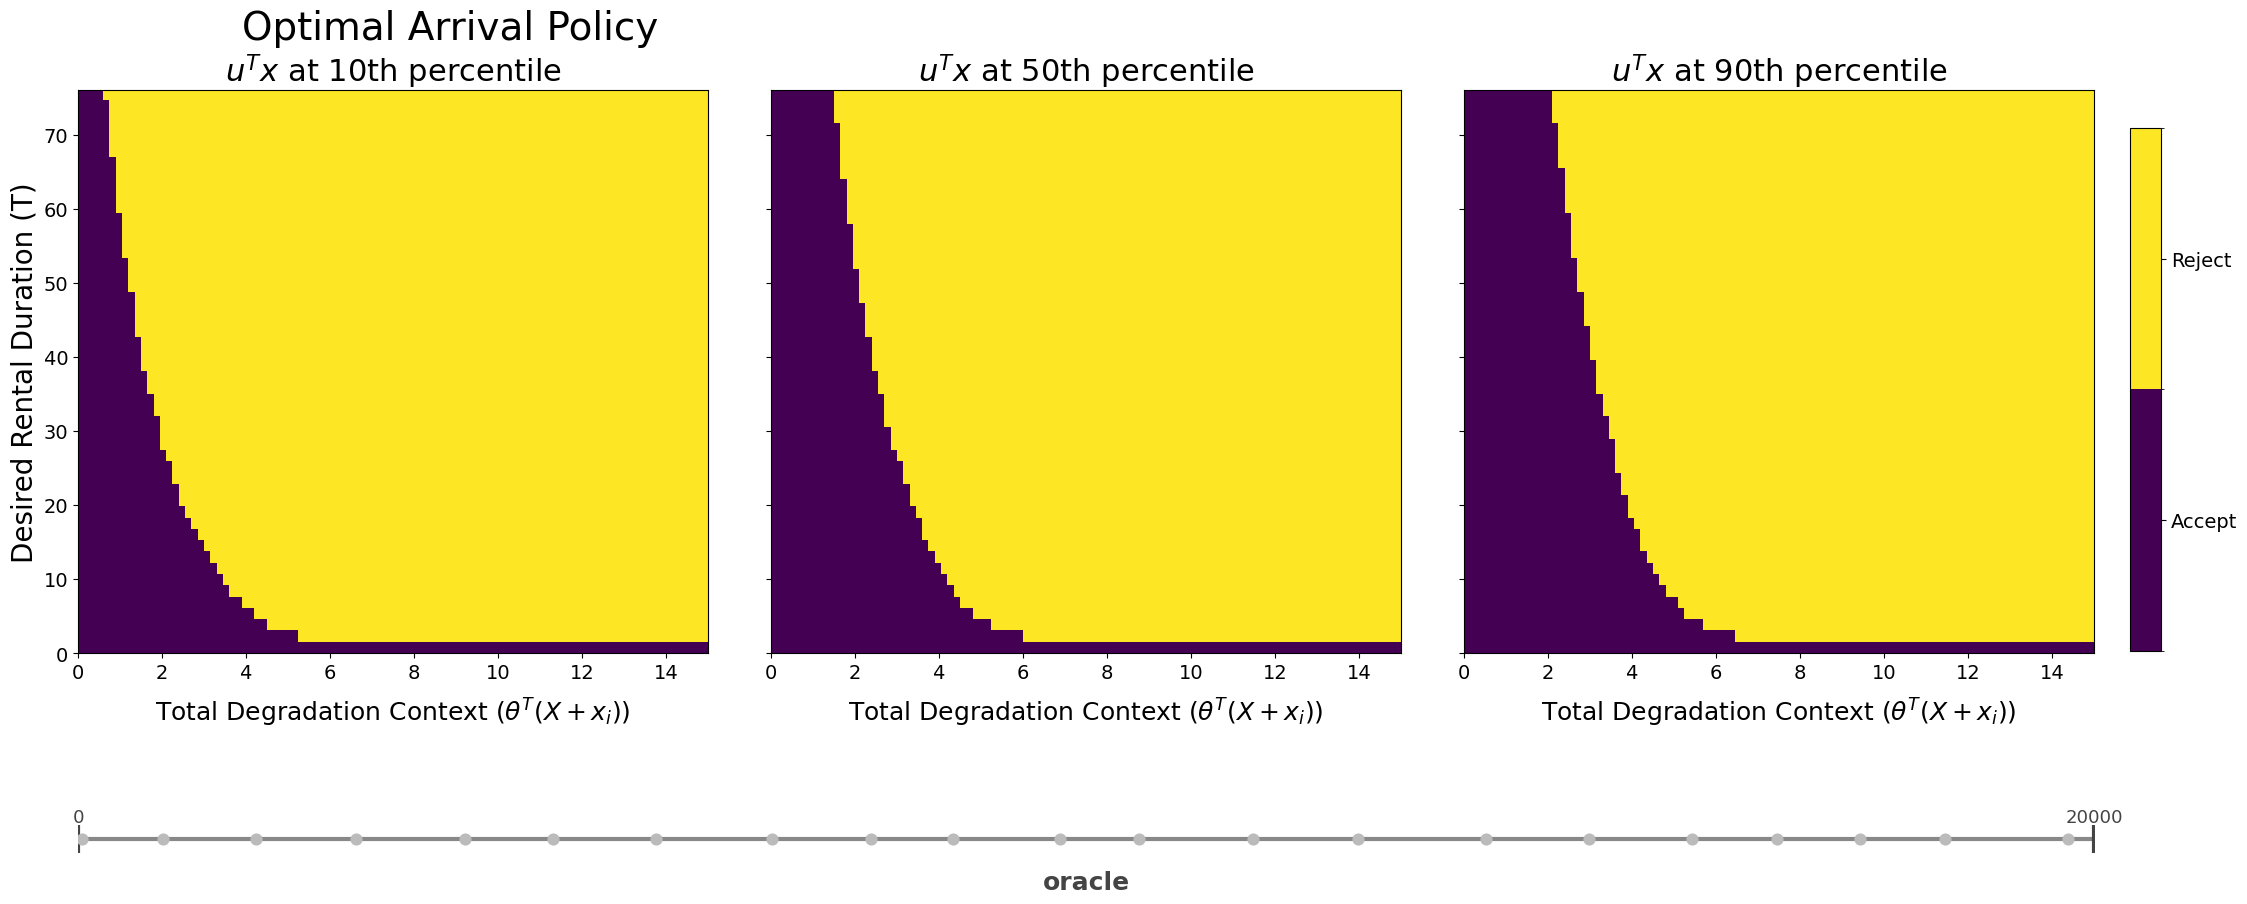

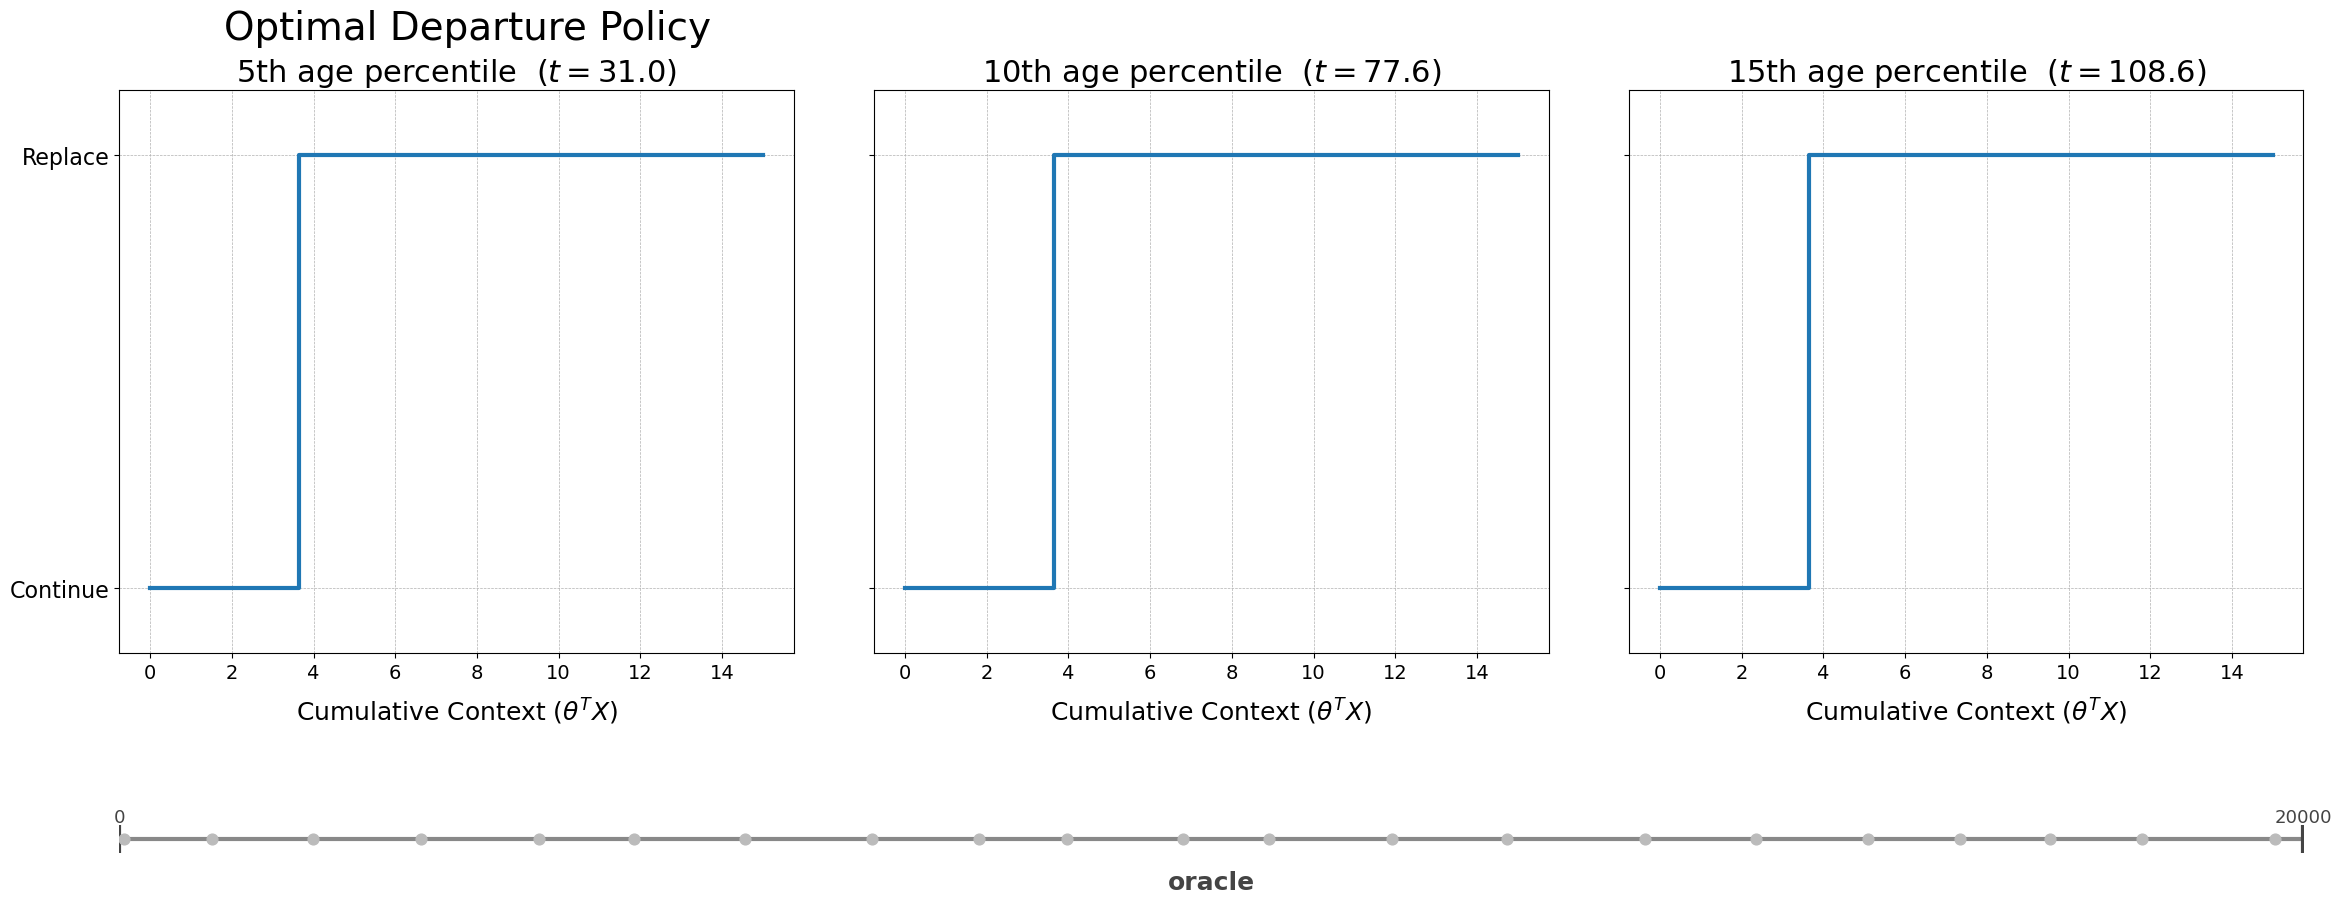

Oracle frames written:
  ../figures/online_policy_evolution/arrival/20260218_011708/epoch_99_optimal.png
  ../figures/online_policy_evolution/departure/20260218_011708/epoch_99_optimal.png


In [11]:
# ---------- oracle tail frame: optimal policy with perfect knowledge of (theta, Lambda_0, u) ----------
#
# This runs value iteration once for the optimal policy via the same
# get_perfect_degradation_learner helper used in plotting.ipynb cell 11. The resulting frame is
# appended as the final image in both GIFs and dwells ~2 s (per-frame duration) so the end of
# the animation is visually obvious.

from raas.utils import get_perfect_degradation_learner

logging.info("Training optimal (oracle) policy via get_perfect_degradation_learner ...")
_, oracle_agent, _ = get_perfect_degradation_learner(
    sample_size=VI_SAMPLES,
    iterations=VI_ITERATIONS,
    mdp_params=mdp_params,
    baseline_hazard_lambda=config.LAMBDA_VAL,
)

# The oracle uses UTILITY_TRUE for u, so recompute u^T x percentiles from UTILITY_TRUE
# to keep the arrival heatmap axis semantically consistent with the oracle's u.
# (The module-level UX_VALS was computed from u_hat_final for the 21 online frames.)
_sampled_true = [customer_gen.generate() for _ in range(10000)]
_ux_true = np.array([np.dot(config.UTILITY_TRUE, c['context']) for c in _sampled_true])
UX_VALS_ORACLE = {p: float(np.percentile(_ux_true, p)) for p in UX_PERCENTILES}
print('UTILITY_TRUE percentiles:', UX_VALS_ORACLE)

# sorts lexicographically after 'epoch_20_cust*.png' and is filtered out by _list_online_frames,
# so the SKIP_ONLINE_LOOP path stays idempotent across reruns.
oracle_base = 'epoch_99_optimal.png'

png_a_oracle = os.path.join(arrival_dir, oracle_base)
fig_a = plot_arrival_epoch(
    oracle_agent, customer_idx=None, total_customers=num_customers_total, epoch_idx=None,
    out_path=png_a_oracle, run_id=run_id,
    optimal_mode=True, ux_vals_override=UX_VALS_ORACLE,
)
plt.show()
plt.close(fig_a)

png_d_oracle = os.path.join(departure_dir, oracle_base)
fig_d = plot_departure_epoch(
    oracle_agent, customer_idx=None, total_customers=num_customers_total, epoch_idx=None,
    out_path=png_d_oracle, run_id=run_id,
    optimal_mode=True,
)
plt.show()
plt.close(fig_d)

# Append to the frame lists consumed by the GIF cells. Guard against double-append when
# re-running just this cell in an open kernel.
if png_a_oracle not in arrival_frame_paths:
    arrival_frame_paths.append(png_a_oracle)
if png_d_oracle not in departure_frame_paths:
    departure_frame_paths.append(png_d_oracle)

print(f"Oracle frames written:\n  {png_a_oracle}\n  {png_d_oracle}")

## Stitch the frames into GIFs

One GIF per policy. Optional — uses Pillow only.

In [12]:
from PIL import Image

NORMAL_FRAME_MS = 200    # per-frame delay for online epochs
FINAL_FRAME_MS = 2000    # per-frame delay for the final oracle frame (lingers so viewer sees "end")


def _stitch_gif(frame_paths, gif_path, normal_ms=NORMAL_FRAME_MS, final_ms=FINAL_FRAME_MS):
    frames = [Image.open(p).convert('P', palette=Image.ADAPTIVE) for p in frame_paths]
    durations = [normal_ms] * (len(frames) - 1) + [final_ms]
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
        optimize=True,
    )
    print(f"Wrote GIF: {gif_path}  ({len(frames)} frames)")


_stitch_gif(
    arrival_frame_paths,
    os.path.join(arrival_dir, f'online_arrival_policy_evolution_{run_id}.gif'),
)

Wrote GIF: ../figures/online_policy_evolution/arrival/20260218_011708/online_arrival_policy_evolution_20260218_011708.gif  (22 frames)


In [13]:
_stitch_gif(
    departure_frame_paths,
    os.path.join(departure_dir, f'online_departure_policy_evolution_{run_id}.gif'),
)

Wrote GIF: ../figures/online_policy_evolution/departure/20260218_011708/online_departure_policy_evolution_20260218_011708.gif  (22 frames)


## Combined 2×3 GIF (arrival + departure stacked)

Composites the existing arrival and departure PNGs into a single 2×3 frame (arrival on top, departure on bottom, one shared progress bar from the departure image). No re-rendering or VI needed — purely image-level composition via Pillow.

In [14]:
# ---------- combined 2x3 GIF: arrival (top) + departure (bottom) with one progress bar ----------

def _detect_bar_crop_y(img, pad_above=50):
    """Find y to crop at so the progress bar is removed from the arrival image.

    Detects the grey hline (#888) of the progress bar — the prominent horizontal line
    spanning much of the image width. Returns hline_y - pad_above so the crop also
    removes the "0" / "20000" tick labels above the hline.
    """
    arr = np.array(img.convert('RGB'))
    h, w, _ = arr.shape
    target = np.array([136, 136, 136])
    hits = (np.abs(arr.astype(int) - target).max(axis=2) < 20).sum(axis=1)
    grey_rows = np.where(hits > w * 0.5)[0]
    if len(grey_rows) == 0:
        return int(h * 0.87)
    lower_grey = grey_rows[grey_rows > h * 0.7]
    hline_y = int(lower_grey.min()) if len(lower_grey) > 0 else int(grey_rows.min())
    return max(0, hline_y - pad_above)


def _pad_to_width(img, target_w, fill=(255, 255, 255)):
    if img.width == target_w:
        return img
    new = Image.new('RGB', (target_w, img.height), fill)
    new.paste(img, ((target_w - img.width) // 2, 0))
    return new


def make_combined_frame(arrival_png, departure_png, out_path):
    a = Image.open(arrival_png).convert('RGB')
    d = Image.open(departure_png).convert('RGB')

    # Crop arrival's progress bar (departure keeps its progress bar — the shared one).
    y_crop = _detect_bar_crop_y(a)
    a_cropped = a.crop((0, 0, a.width, y_crop))

    # Pad to same width (arrival has a right-side colorbar; departure does not).
    W = max(a_cropped.width, d.width)
    a_cropped = _pad_to_width(a_cropped, W)
    d_padded = _pad_to_width(d, W)

    # Vertical stack
    H = a_cropped.height + d_padded.height
    combined = Image.new('RGB', (W, H), (255, 255, 255))
    combined.paste(a_cropped, (0, 0))
    combined.paste(d_padded, (0, a_cropped.height))
    combined.save(out_path, format='PNG', optimize=True)
    return out_path


# ---------- build combined frames ----------
combined_dir = os.path.join(OUT_DIR_ROOT, 'combined', run_id)
os.makedirs(combined_dir, exist_ok=True)
print(f"Combined frames -> {combined_dir}")

assert len(arrival_frame_paths) == len(departure_frame_paths), (
    f"arrival ({len(arrival_frame_paths)}) and departure ({len(departure_frame_paths)}) "
    f"frame lists must be the same length"
)

combined_frame_paths = []
for a_path, d_path in zip(arrival_frame_paths, departure_frame_paths):
    base = os.path.basename(a_path)
    out = os.path.join(combined_dir, base)
    make_combined_frame(a_path, d_path, out)
    combined_frame_paths.append(out)

print(f"Composited {len(combined_frame_paths)} combined frames.")

# ---------- stitch combined GIF ----------
_stitch_gif(
    combined_frame_paths,
    os.path.join(combined_dir, f'online_policy_evolution_combined_{run_id}.gif'),
)

Combined frames -> ../figures/online_policy_evolution/combined/20260218_011708
Composited 22 combined frames.
Wrote GIF: ../figures/online_policy_evolution/combined/20260218_011708/online_policy_evolution_combined_20260218_011708.gif  (22 frames)
